In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tqdm.auto as tqdm
import numpy as np
from scipy.stats import pearsonr
import tqdm as t
from scipy import stats
from statsmodels.stats.multitest import multipletests

from dti.data import load_kinodata, load_landrum

t.tqdm.pandas()

# Read prediction data

In [3]:
runs = """
kinodata_small_good_allsets_0
kinodata_small_good_allsets_1
kinodata_small_good_allsets_2
kinodata_small_good_allsets_3
kinodata_small_good_allsets_4
kinodata_small_good_ic50_0
kinodata_small_good_ic50_1
kinodata_small_good_ic50_2
kinodata_small_good_ic50_3
kinodata_small_good_ic50_4
kinodata_small_good_sets_0
kinodata_small_good_sets_1
kinodata_small_good_sets_2
kinodata_small_good_sets_3
kinodata_small_good_sets_4
kinodata_good_allsets_0
kinodata_good_allsets_1
kinodata_good_allsets_2
kinodata_good_allsets_3
kinodata_good_allsets_4
kinodata_good_ic50_0
kinodata_good_ic50_1
kinodata_good_ic50_2
kinodata_good_ic50_3
kinodata_good_ic50_4
kinodata_good_sets_0
kinodata_good_sets_1
kinodata_good_sets_2
kinodata_good_sets_3
kinodata_good_sets_4
kinodata_morgan_0_allsets
kinodata_morgan_0_ic50_66f8
kinodata_morgan_0_sets_5c05
kinodata_morgan_1_allsets
kinodata_morgan_1_ic50_5f6e
kinodata_morgan_1_sets_b458
kinodata_morgan_2_allsets
kinodata_morgan_2_ic50_4523
kinodata_morgan_2_sets_0392
kinodata_morgan_3_allsets
kinodata_morgan_3_ic50_47d5
kinodata_morgan_3_sets_e67e
kinodata_morgan_4_allsets
kinodata_morgan_4_ic50_5e6b
kinodata_morgan_4_sets_9751
kinodata_small_allsets_0
kinodata_small_allsets_1
kinodata_small_allsets_2
kinodata_small_allsets_3
kinodata_small_allsets_4
kinodata_small_ic50_0
kinodata_small_ic50_1
kinodata_small_ic50_2
kinodata_small_ic50_3
kinodata_small_ic50_4
kinodata_small_sets_0
kinodata_small_sets_1
kinodata_small_sets_2
kinodata_small_sets_3
kinodata_small_sets_4
landrum_bad_allsets_0
landrum_bad_allsets_1
landrum_bad_allsets_2
landrum_bad_allsets_3
landrum_bad_allsets_4
landrum_bad_ic50_0
landrum_bad_ic50_1
landrum_bad_ic50_2
landrum_bad_ic50_3
landrum_bad_ic50_4
landrum_bad_sets_0
landrum_bad_sets_1
landrum_bad_sets_2
landrum_bad_sets_3
landrum_bad_sets_4
landrum_large_allsets_0
landrum_large_allsets_1
landrum_large_allsets_2
landrum_large_allsets_3
landrum_large_allsets_4
landrum_large_ic50_0
landrum_large_ic50_1
landrum_large_ic50_2
landrum_large_ic50_3
landrum_large_ic50_4
landrum_large_sets_0
landrum_large_sets_1
landrum_large_sets_2
landrum_large_sets_3
landrum_large_sets_4
landrum_morgan_0_allsets
landrum_morgan_0_ic50_402f
landrum_morgan_0_sets_6fb1
landrum_morgan_1_allsets
landrum_morgan_1_ic50_4643
landrum_morgan_1_sets_9ef8
landrum_morgan_2_allsets
landrum_morgan_2_ic50_0bde
landrum_morgan_2_sets_0651
landrum_morgan_3_allsets
landrum_morgan_3_ic50_db6b
landrum_morgan_3_sets_04c3
landrum_morgan_4_allsets
landrum_morgan_4_ic50_af10
landrum_morgan_4_sets_7497
omnivore_morgan_0_ic50_d9d1
omnivore_morgan_1_ic50_ce7d
omnivore_morgan_2_ic50_5bb3
omnivore_morgan_3_ic50_ab79
omnivore_morgan_4_ic50_f970
omnivore_morgan_0_allsets
omnivore_morgan_0_sets_1e02
omnivore_morgan_1_allsets
omnivore_morgan_1_sets_c799
omnivore_morgan_2_allsets
omnivore_morgan_2_sets_481a
omnivore_morgan_3_allsets
omnivore_morgan_3_sets_c87c
omnivore_morgan_4_allsets
omnivore_morgan_4_sets_334c""".split()

In [4]:
dataset_renaming = {
    'landrum': 'chembl-curated',
    'landrum_large': 'chembl-hc',
    'landrum_bad': 'chembl-cs',
    'omnivore': 'chembl-all',
    'kinodata': 'kinodata',
    'kinodata_small': 'kinodata-cs',
    'kinodata_good': 'kinodata-hc',
    'kinodata_small_good': 'kinodata-curated',
}
dataset_renaming_ = {v: k for k, v in dataset_renaming.items()}

In [5]:
all_preds = []
for run in tqdm.tqdm(runs):
    parts = run.split("_")
    if run.startswith("kinodata_small_good"):
        dataset, fold, method = "_".join(parts[0:3]), parts[4], parts[3]
    else:
        dataset, fold, method = "_".join(parts[0:2]), parts[3], parts[2]
    if dataset.endswith("morgan"):
        dataset = dataset[:-len("_morgan")]
        if fold in {'sets', 'allsets', 'ic50'}:
            fold, method = method, fold
    try:
        df = pd.read_csv(f"../data/hpc-data/{run}/predictions.csv")
    except:
        print('fail on', run)
        continue
    df["dataset"] = dataset_renaming[dataset]
    df["fold"] = fold
    df["method"] = method
    all_preds.append(df)
df = pd.concat(all_preds)

  0%|          | 0/120 [00:00<?, ?it/s]

# Correlations over the entire test set (IC50 only)

In [6]:
overall_corrs = (
    df[df["method"] == "ic50"]
    .groupby(["dataset", "fold"])
    .corr(method='pearson', numeric_only=True)
    .loc[:, :, "prediction"]["label"]
    .reset_index()
)
overall_corrs

,dataset,fold,label
0,chembl-all,0,0.651396
1,chembl-all,1,0.664045
2,chembl-all,2,0.629280
3,chembl-all,3,0.649104
4,chembl-all,4,0.655305
5,chembl-cs,0,0.541633
6,chembl-cs,1,0.523631
7,chembl-cs,2,0.591228
8,chembl-cs,3,0.543652
9,chembl-cs,4,0.559345


# Dataset sizes

In [7]:
!wc -l ../data/raw/{landrum,omnivore,kinodata}*.csv

    388899 ../data/raw/landrum_bad.csv
    259824 ../data/raw/landrum.csv
    537735 ../data/raw/landrum_large.csv
    838156 ../data/raw/omnivore.csv
    140978 ../data/raw/kinodata3d_meta.csv
    211608 ../data/raw/kinodata.csv
    135001 ../data/raw/kinodata_good.csv
     84888 ../data/raw/kinodata_small.csv
     56195 ../data/raw/kinodata_small_good.csv
   2653284 total


# Assay-Aggregate Correlations

In [8]:
overall = []
corrs = []
removed_assays = {ds: [] for ds in overall_corrs['dataset'].unique()}
too_small = 0
label_var = 0
pred_var = 0
for (dataset, fold, method), d in tqdm.tqdm(df.groupby(["dataset", "fold", "method"])):
    sizes = []
    pearsons = []
    for assay_id, g in d.groupby("assay_id"):
        if assay_id in removed_assays[dataset]:
            continue
        size = len(g)
        if size <= 2:
            too_small += 1
            removed_assays[dataset].append(assay_id)
            continue
        if np.std(g["label"].values) < 1e-9:
            label_var += 1
            removed_assays[dataset].append(assay_id)
            continue
        if np.std(g["prediction"].values) < 1e-9:
            pred_var += 1
            removed_assays[dataset].append(assay_id)
            continue
        corr = pearsonr(g["label"].values, g["prediction"].values)[0]

        corrs.append(
            dict(
                dataset=dataset,
                fold=fold,
                method=method,
                assay_id=assay_id,
                size=size,
                pearson=corr,
            )
        )
        sizes.append(size)
        pearsons.append(corr)
    pearsons = np.clip(pearsons, -1.0 + 1e-6, 1.0 - 1e-6)

    z_values = np.arctanh(pearsons)

    weights = np.array(sizes) - 3
    weights = np.maximum(weights, 1)
    avg_z = np.average(z_values, weights=weights)

    mean_pearson = np.tanh(avg_z)

    overall.append(
        dict(dataset=dataset, fold=fold, method=method, pearson=mean_pearson)
    )
    # print(f"dataset={dataset} fold={fold} method={method} corr={mean_pearson:.4f}")
assay_corrs = pd.DataFrame(overall)
corrs = pd.DataFrame(corrs)

  0%|          | 0/120 [00:00<?, ?it/s]

In [9]:
too_small, label_var, pred_var

(0, 538, 191)

In [10]:
method_order = ["ic50", "allsets", "sets"]
method_labels = {
    "ic50": "pointwise prediction",
    "allsets": "ranking (trained on random sets)",
    "sets": "ranking (trained on assay sets)",
    "overall ic50": "overall ic50",
}
for d in [corrs, assay_corrs]:
    d["method"] = pd.Categorical(d["method"], categories=method_order, ordered=True)
    d["method_label"] = d["method"].map(method_labels)

In [11]:
assay_corrs

,dataset,fold,method,pearson,method_label
0,chembl-all,0,allsets,0.461908,ranking (trained on random sets)
1,chembl-all,0,ic50,0.449631,pointwise prediction
2,chembl-all,0,sets,0.468333,ranking (trained on assay sets)
3,chembl-all,1,allsets,0.446665,ranking (trained on random sets)
4,chembl-all,1,ic50,0.439427,pointwise prediction
...,...,...,...,...,...
115,kinodata-hc,3,ic50,0.390519,pointwise prediction
116,kinodata-hc,3,sets,0.453375,ranking (trained on assay sets)
117,kinodata-hc,4,allsets,0.386152,ranking (trained on random sets)
118,kinodata-hc,4,ic50,0.343914,pointwise prediction


In [12]:
summary = assay_corrs.pivot(
    index=["dataset", "fold"], columns="method_label", values="pearson"
)
summary

method_label           pointwise prediction  ranking (trained on random sets)  \
dataset          fold                                                           
chembl-all       0                 0.449631                          0.461908   
                 1                 0.439427                          0.446665   
                 2                 0.440797                          0.459806   
                 3                 0.445052                          0.457705   
                 4                 0.442111                          0.449881   
chembl-cs        0                 0.399827                          0.425837   
                 1                 0.378995                          0.404119   
                 2                 0.427760                          0.437199   
                 3                 0.393583                          0.416043   
                 4                 0.389746                          0.420274   
chembl-curated   0                 0.348672                          0.372403   
                 1                 0.365828                          0.390505   
                 2                 0.358350                          0.384429   
                 3                 0.374677                          0.388425   
                 4                 0.367806                          0.381644   
chembl-hc        0                 0.405181                          0.428345   
                 1                 0.388653                          0.407369   
                 2                 0.422211                          0.434835   
                 3                 0.410341                          0.426078   
                 4                 0.398982                          0.413114   
kinodata         0                 0.375309                          0.402009   
                 1                 0.426039                          0.442679   
                 2                 0.364420                          0.364693   
                 3                 0.375278                          0.374512   
                 4                 0.369384                          0.401928   
kinodata-cs      0                 0.356571                          0.393166   
                 1                 0.334694                          0.373269   
                 2                 0.348171                          0.372128   
                 3                 0.362489                          0.397709   
                 4                 0.316551                          0.351012   
kinodata-curated 0                 0.286732                          0.292198   
                 1                 0.317095                          0.331982   
                 2                 0.293781                          0.323162   
                 3                 0.319187                          0.348793   
                 4                 0.283258                          0.318478   
kinodata-hc      0                 0.359211                          0.390954   
                 1                 0.359624                          0.353593   
                 2                 0.358282                          0.366719   
                 3                 0.390519                          0.424386   
                 4                 0.343914                          0.386152   

method_label           ranking (trained on assay sets)  
dataset          fold                                   
chembl-all       0                            0.468333  
                 1                            0.455915  
                 2                            0.467846  
                 3                            0.460385  
                 4                            0.453477  
chembl-cs        0                            0.447570  
                 1                            0.435497  
                 2                            0.455144  
                 3         

In [13]:
print(summary.to_latex(float_format="%.4f"))

\begin{tabular}{llrrr}
\toprule
 & method_label & pointwise prediction & ranking (trained on random sets) & ranking (trained on assay sets) \\
dataset & fold &  &  &  \\
\midrule
\multirow[t]{5}{*}{chembl-all} & 0 & 0.4496 & 0.4619 & 0.4683 \\
 & 1 & 0.4394 & 0.4467 & 0.4559 \\
 & 2 & 0.4408 & 0.4598 & 0.4678 \\
 & 3 & 0.4451 & 0.4577 & 0.4604 \\
 & 4 & 0.4421 & 0.4499 & 0.4535 \\
\cline{1-5}
\multirow[t]{5}{*}{chembl-cs} & 0 & 0.3998 & 0.4258 & 0.4476 \\
 & 1 & 0.3790 & 0.4041 & 0.4355 \\
 & 2 & 0.4278 & 0.4372 & 0.4551 \\
 & 3 & 0.3936 & 0.4160 & 0.4371 \\
 & 4 & 0.3897 & 0.4203 & 0.4433 \\
\cline{1-5}
\multirow[t]{5}{*}{chembl-curated} & 0 & 0.3487 & 0.3724 & 0.4022 \\
 & 1 & 0.3658 & 0.3905 & 0.4229 \\
 & 2 & 0.3584 & 0.3844 & 0.4105 \\
 & 3 & 0.3747 & 0.3884 & 0.4204 \\
 & 4 & 0.3678 & 0.3816 & 0.4029 \\
\cline{1-5}
\multirow[t]{5}{*}{chembl-hc} & 0 & 0.4052 & 0.4283 & 0.4383 \\
 & 1 & 0.3887 & 0.4074 & 0.4114 \\
 & 2 & 0.4222 & 0.4348 & 0.4469 \\
 & 3 & 0.4103 & 0.4261 & 0.4467 \

In [14]:
df = assay_corrs
df["z"] = np.arctanh(df["pearson"])


def cohen_d_pooled(x1, x2):
    n1, n2 = len(x1), len(x2)
    v1, v2 = np.var(x1, ddof=1), np.var(x2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
    return (np.mean(x1) - np.mean(x2)) / pooled_std


comparisons = [
    ("ic50", "allsets", "IC50 < ranking (inter-assay)"),
    ("ic50", "sets", "IC50 < ranking (intra-assay)"),
    ("allsets", "sets", "ranking (inter-assay) < ranking (intra-assay)"),
]

results = []
for ds in df["dataset"].unique():
    ds_df = df[df["dataset"] == ds]
    for m1, m2, label in comparisons:
        v1 = ds_df[ds_df["method"] == m1].sort_values("fold")["z"].values
        v2 = ds_df[ds_df["method"] == m2].sort_values("fold")["z"].values

        t_stat, p_t_2sided = stats.ttest_rel(v1, v2)
        p_t_onesided = p_t_2sided / 2 if t_stat < 0 else 1 - (p_t_2sided / 2)

        w_stat, p_w_onesided = stats.wilcoxon(v1, v2, alternative="less")

        d = cohen_d_pooled(v1, v2)

        results.append(
            {
                "dataset": ds,
                "comparison": label,
                "t_stat": t_stat,
                "w_stat": w_stat,
                "p_t_raw": p_t_onesided,
                "p_w_raw": p_w_onesided,
                "d": d,
            }
        )

p_t_all = [r["p_t_raw"] for r in results]
p_w_all = [r["p_w_raw"] for r in results]

_, p_t_fdr, _, _ = multipletests(p_t_all, method="fdr_bh")
_, p_w_fdr, _, _ = multipletests(p_w_all, method="fdr_bh")

for i in range(len(results)):
    results[i]["t-test (FDR)"] = p_t_fdr[i]
    results[i]["Wilcoxon (FDR)"] = p_w_fdr[i]

res_df = pd.DataFrame(results)

# Rename columns for a cleaner LaTeX table output
res_df = res_df.rename(
    columns={"t_stat": "t-statistic", "w_stat": "Wilcoxon-statistic"}
)

# Included 't-statistic' and 'Wilcoxon-statistic' into the final columns selection
cols = [
    "dataset",
    "comparison",
    "t-statistic",
    "t-test (FDR)",
    "Wilcoxon-statistic",
    "Wilcoxon (FDR)",
    "d",
]

print(
    res_df[cols]
    .set_index(["dataset", "comparison"])
    .to_latex(index=True, float_format="%.4f")
)

\begin{tabular}{llrrrrr}
\toprule
 &  & t-statistic & t-test (FDR) & Wilcoxon-statistic & Wilcoxon (FDR) & d \\
dataset & comparison &  &  &  &  &  \\
\midrule
\multirow[t]{3}{*}{chembl-all} & IC50 < ranking (inter-assay) & -5.5291 & 0.0039 & 0.0000 & 0.0375 & -2.1519 \\
 & IC50 < ranking (intra-assay) & -6.7778 & 0.0023 & 0.0000 & 0.0375 & -3.1733 \\
 & ranking (inter-assay) < ranking (intra-assay) & -4.7726 & 0.0056 & 0.0000 & 0.0375 & -0.8986 \\
\cline{1-7}
\multirow[t]{3}{*}{chembl-cs} & IC50 < ranking (inter-assay) & -6.4713 & 0.0025 & 0.0000 & 0.0375 & -1.4554 \\
 & IC50 < ranking (intra-assay) & -9.2792 & 0.0010 & 0.0000 & 0.0375 & -3.2630 \\
 & ranking (inter-assay) < ranking (intra-assay) & -10.7289 & 0.0009 & 0.0000 & 0.0375 & -2.2388 \\
\cline{1-7}
\multirow[t]{3}{*}{chembl-curated} & IC50 < ranking (inter-assay) & -7.5447 & 0.0017 & 0.0000 & 0.0375 & -2.3755 \\
 & IC50 < ranking (intra-assay) & -12.6088 & 0.0007 & 0.0000 & 0.0375 & -4.9879 \\
 & ranking (inter-assay) < rank

In [15]:
res_df[cols].set_index(["dataset", "comparison"])

t-statistic  \
dataset          comparison                                                   
chembl-all       IC50 < ranking (inter-assay)                     -5.529113   
                 IC50 < ranking (intra-assay)                     -6.777825   
                 ranking (inter-assay) < ranking (intra-assay)    -4.772569   
chembl-cs        IC50 < ranking (inter-assay)                     -6.471253   
                 IC50 < ranking (intra-assay)                     -9.279160   
                 ranking (inter-assay) < ranking (intra-assay)   -10.728931   
chembl-curated   IC50 < ranking (inter-assay)                     -7.544710   
                 IC50 < ranking (intra-assay)                    -12.608821   
                 ranking (inter-assay) < ranking (intra-assay)   -13.227762   
chembl-hc        IC50 < ranking (inter-assay)                     -9.103568   
                 IC50 < ranking (intra-assay)                     -4.920744   
                 ranking (inter-assay) < ranking (intra-assay)    -1.802921   
kinodata         IC50 < ranking (inter-assay)                     -2.252607   
                 IC50 < ranking (intra-assay)                    -19.029445   
                 ranking (inter-assay) < ranking (intra-assay)    -8.160998   
kinodata-cs      IC50 < ranking (inter-assay)                    -13.121478   
                 IC50 < ranking (intra-assay)                    -10.234032   
                 ranking (inter-assay) < ranking (intra-assay)    -5.734279   
kinodata-curated IC50 < ranking (inter-assay)                     -4.166164   
                 IC50 < ranking (intra-assay)                    -10.568010   
                 ranking (inter-assay) < ranking (intra-assay)    -9.610404   
kinodata-hc      IC50 < ranking (inter-assay)                     -2.462654   
                 IC50 < ranking (intra-assay)                     -5.046077   
                 ranking (inter-assay) < ranking (intra-assay)    -3.405901   

                                                                t-test (FDR)  \
dataset          comparison                                                    
chembl-all       IC50 < ranking (inter-assay)                       0.003921   
                 IC50 < ranking (intra-assay)                       0.002283   
                 ranking (inter-assay) < ranking (intra-assay)      0.005573   
chembl-cs        IC50 < ranking (inter-assay)                       0.002518   
                 IC50 < ranking (intra-assay)                       0.000969   
                 ranking (inter-assay) < ranking (intra-assay)      0.000881   
chembl-curated   IC50 < ranking (inter-assay)                       0.001653   
                 IC50 < ranking (intra-assay)                       0.000683   
                 ranking (inter-assay) < ranking (intra-assay)      0.000683   
chembl-hc        IC50 < ranking (inter-assay)                       0.000969   
                 IC50 < ranking (intra-assay)                       0.005283   
                 ranking (inter-assay) < ranking (intra-assay)      0.072871   
kinodata         IC50 < ranking (inter-assay)                       0.045596   
                 IC50 < ranking (intra-assay)                       0.000539   
                 ranking (inter-assay) < ranking (intra-assay)      0.001339   
kinodata-cs      IC50 < ranking (inter-assay)                       0.000683   
                 IC50 < ranking (intra-assay)                       0.000881   
                 ranking (inter-assay) < ranking (intra-assay)      0.003665   
kinodata-curated IC50 < ranking (inter-assay)                       0.008445   
                 IC50 < ranking (intra-assay)                       0.000881   
                 ranking (inter-assay) < ranking (intra-assay)      0.000969   
kinodata-hc      IC50 < ranking (inter-assay)                       0.037905   
                 IC50 < ranking (intra-assay)                       0.005118   
         

In [16]:
method_order = ["ic50", "allsets", "sets"]
method_labels = {
    "ic50": "pointwise prediction",
    "allsets": "ranking (trained on random sets)",
    "sets": "ranking (trained on assay sets)",
    "overall ic50": "overall ic50",
}
for d in [corrs, assay_corrs]:
    d["method"] = pd.Categorical(d["method"], categories=method_order, ordered=True)
    d["method_label"] = d["method"].map(method_labels)

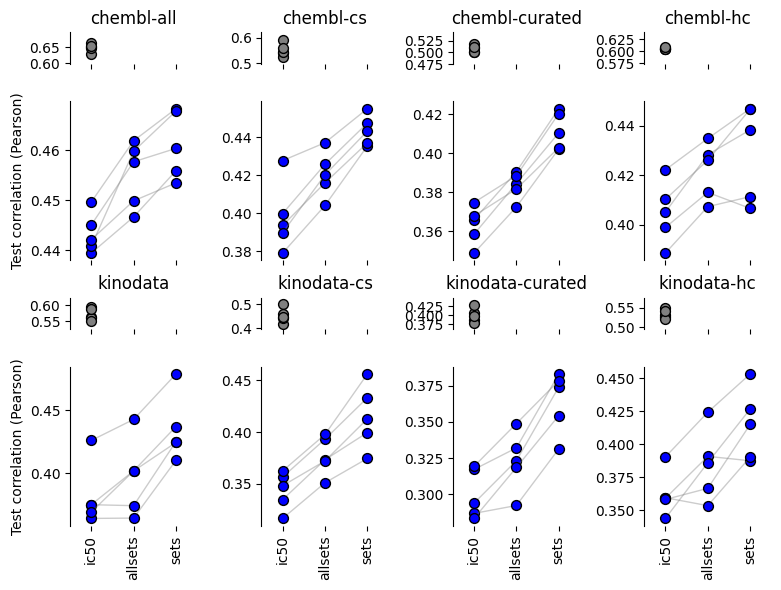

In [17]:
metric = "pearson"
fig, axes = plt.subplots(
    nrows=4, ncols=4, sharex=True, sharey=False, figsize=(4*2, 3 * 2), height_ratios=[1, 5] * 2
)
plot_kws = dict(color="gray", alpha=0.4, linewidth=1, zorder=9)
scatter_kws = dict(zorder=9, s=50, marker="o", edgecolors="black", linewidths=1)
for ax, (dataset, subdf) in zip(axes[[0, 2]].flatten(), overall_corrs.groupby("dataset")):
    ax.set_title(dataset)
    corrs_total = subdf["label"].values
    ax.scatter(
        [0] * len(subdf), corrs_total, label="overall", color="gray", **scatter_kws
    )
    ax.set_ylim(corrs_total.min() * 0.95, corrs_total.max() * 1.05)
    ax.set_xticks([], [])
    sns.despine(ax=ax, bottom=True)
for ax, (dataset, subdf) in zip(axes[[1, 3]].flatten(), assay_corrs.groupby("dataset")):
    for fold, fold_df in subdf.groupby("fold"):
        fold_df = fold_df.sort_values("method")
        ax.plot(fold_df["method_label"], fold_df[metric], **plot_kws)
        ax.scatter(
            fold_df["method_label"],
            fold_df[metric],
            color="blue",
            label="per-set",
            **scatter_kws,
        )
        ax.set_xticks([0, 1, 2], method_order)  # ['a', 'b', 'c'])
        ax.tick_params("x", rotation=90)
        ax.set_xlim(-0.5, 2.5)
        # ax.set_ylim(0.35,.5)
        sns.despine(ax=ax, bottom=True)
axes[1][0].set_ylabel("Test correlation (Pearson)")
axes[3][0].set_ylabel("Test correlation (Pearson)")
# plt.legend()
plt.tight_layout()
# fig.subplots_adjust(hspace=2)
plt.savefig("results.pdf")

# Identify test sets with overlap

In [18]:
try:
    assays_df = pd.read_csv('assays_df.csv')
except:
    import sqlite3
    import pandas as pd
    
    db_path = "../data/chembl_32/chembl_32_sqlite/chembl_32.db"
    conn = sqlite3.connect(db_path)
    assays_df = pd.read_sql_query("SELECT * FROM assays;", conn)
    
    assays_df.to_csv("assays_df.csv")

/tmp/ipykernel_331084/286972271.py:2: DtypeWarning: Columns (5,6,9,18,24) have mixed types. Specify dtype option on import or set low_memory=False.
  assays_df = pd.read_csv('assays_df.csv')


In [83]:
def overlaps(dataset_name):
    dataset_name = dataset_renaming_[dataset_name]
    col_doc = 'docs.chembl_id' if "kinodata" in dataset_name else "doc_id"
    overlaps = []
    doc_overlaps = []
    tgt_overlaps = []
    dataset = (load_kinodata if "kinodata" in dataset_name else load_landrum)(f"../data/raw/{dataset_name}.csv")
    dataset = dataset.merge(assays_df[['assay_id', 'confidence_score']], on='assay_id')
    dataset = dataset.rename(columns={col_doc: "doc_id"})
    if "kinodata" in dataset_name:
        dataset['doc_id'] = dataset['doc_id'].str[6:].astype(int)
    assay_to_doc = (
        dataset[['assay_id', "doc_id"]]
        .drop_duplicates('assay_id')
    )
    for fold in tqdm.tqdm(range(5)):
        test = pd.read_csv(f"../data/processed/{dataset_name}/{fold}/test.csv", index_col=0)
        train = pd.read_csv(f"../data/processed/{dataset_name}/{fold}/train.csv", index_col=0)
        test = test.merge(assay_to_doc, on='assay_id', how='left')
        train = train.merge(assay_to_doc, on='assay_id', how='left')
        duplicates = test.merge(
            train[["compound_id", "assay_id", "target", "activity_value"]],
            on=["compound_id", "target", "activity_value"],
            how="inner",
        )
        duplicate_docs = np.intersect1d(test["doc_id"].unique(), train["doc_id"].unique())
        doc_overlaps.append(test[test["doc_id"].isin(duplicate_docs)]['assay_id'].unique())
        duplicate_tgts = np.intersect1d(test['target'].unique(), train['target'].unique())
        tgt_overlaps.append(test[test['target'].isin(duplicate_tgts)]['assay_id'].unique())
        overlaps.append(duplicates["assay_id_x"].unique())

    return (
        np.unique(np.concat(overlaps)),
        np.unique(np.concat(doc_overlaps)),
        np.unique(np.concat(tgt_overlaps))
    )

In [84]:
def bysize(corrs, clip=1e-10):
    rows = []
    for (dataset, method), d in corrs.groupby(["dataset", "method"]):
        print(dataset, method)
        for thres in tqdm.tqdm(range(d["size"].max())):
            subset = d[(d["size"] <= thres) & (~d["pearson"].isna())]
            aggcorr = np.tanh(
                (
                    np.atanh(np.clip(subset["pearson"], -1 + clip, 1 - clip))
                    * (subset["size"] - 3)
                ).sum()
                / (subset["size"] - 3).sum()
            )
            rows.append(
                dict(dataset=dataset, method=method, pearson=aggcorr, threshold=thres)
            )
    return pd.DataFrame(rows)

def bysize_q(corrs, q=10, clip=1e-10):
    if len(corrs) == 0:
        return None
    rows = []

    for (dataset, method), d in corrs.groupby(["dataset", "method"], observed=True):
        print(dataset, method)

        d = d.copy()

        d["size_quantile"] = pd.qcut(
            d["size"],
            q=q,
            duplicates="drop",
        )

        for quantile, subset in d.groupby("size_quantile", observed=True):
            subset = subset[~subset["pearson"].isna()]

            if subset.empty:
                continue

            weights = subset["size"] - 3
            aggcorr = np.tanh(
                (
                    np.atanh(
                        np.clip(subset["pearson"], -1 + clip, 1 - clip)
                    )
                    * weights
                ).sum()
                / weights.sum()
            )

            rows.append(
                dict(
                    dataset=dataset,
                    method=method,
                    pearson=aggcorr,
                    quantile=quantile,
                )
            )

    res = pd.DataFrame(rows)
    res = res.sort_values("quantile")
    res["quantile_label"] = res["quantile"].apply(
        lambda x: f"{round(x.left):d}–{round(x.right):d}"
    )
    return res

def bysize_q_analytical(corrs, q=10, clip=1e-10, alpha=0.05):
    if len(corrs) == 0:
        return None
    rows = []
    z_crit = 1.96  # 95% CI normal critical value

    for (dataset, method), d in corrs.groupby(
        ["dataset", "method"], observed=True
    ):
        d = d.dropna(subset=["pearson"]).copy()
        if d.empty:
            continue

        d["size_quantile"] = pd.qcut(d["size"], q=q, duplicates="drop")

        for quantile, subset in d.groupby("size_quantile", observed=True):
            if subset.empty:
                continue

            r = np.clip(subset["pearson"].values, -1 + clip, 1 - clip)
            weights = subset["size"].values - 3

            # Skip bins where weights sum to 0 or negative
            if weights.sum() <= 0:
                continue

            # Fisher z-transformation
            z = np.atanh(r)
            w_sum = weights.sum()

            # Weighted average Fisher z
            z_avg = (z * weights).sum() / w_sum
            aggcorr = np.tanh(z_avg)

            # Analytical Standard Error in z-space
            se_z = 1.0 / np.sqrt(w_sum)

            # Analytical 95% CI bounds in r-space
            ci_lower = np.tanh(z_avg - z_crit * se_z)
            ci_upper = np.tanh(z_avg + z_crit * se_z)

            rows.append(
                dict(
                    dataset=dataset,
                    method=method,
                    pearson=aggcorr,
                    ci_lower=ci_lower,
                    ci_upper=ci_upper,
                    quantile=quantile,
                )
            )

    if not rows:
        return None

    res = pd.DataFrame(rows).sort_values("quantile")
    res["quantile_label"] = res["quantile"].apply(
        lambda x: f"{round(x.left):d}–{round(x.right):d}"
    )
    return res

def bysize_q_not_aggro(corrs, q=5):
    if len(corrs) == 0:
        return None

    dfs = []
    for (dataset, method), d in corrs.groupby(["dataset", "method"], observed=True):
        d = d.dropna(subset=["pearson"]).copy()
        if d.empty:
            continue

        d["quantile"] = pd.qcut(d["size"], q=q, duplicates="drop")

        d["quantile_label"] = d["quantile"].apply(
            lambda x: f"{round(x.left):d}–{round(x.right):d}"
        )
        dfs.append(d)

    if not dfs:
        return None

    res = pd.concat(dfs, ignore_index=True)
    res = res.sort_values("quantile")
    return res

In [85]:
def plot_stratified_corrs(df_agg, ax, dodge=0.15):
    methods = df_agg["method"].unique()
    quantiles = df_agg["quantile_label"].unique()

    # Map categorical quantile labels to integer x-positions (0, 1, 2...)
    q_map = {q: i for i, q in enumerate(quantiles)}
    x_base = df_agg["quantile_label"].map(q_map)

    # Compute horizontal offsets for each method
    offsets = np.linspace(-dodge, dodge, len(methods))
    method_offsets = dict(zip(methods, offsets))

    for m in methods:
        sub = df_agg[df_agg["method"] == m]
        x_pos = sub["quantile_label"].map(q_map) + method_offsets[m]

        # Calculate symmetric/asymmetric error lengths from bounds
        yerr_lower = sub["pearson"] - sub["ci_lower"]
        yerr_upper = sub["ci_upper"] - sub["pearson"]

        ax.errorbar(
            x=x_pos,
            y=sub["pearson"],
            yerr=[yerr_lower, yerr_upper],
            label=m,
            fmt="-o",  # Line + circle marker
            capsize=3,
            capthick=1,
            alpha=0.85,
        )

    # Re-apply categorical x-axis ticks
    ax.set_xticks(range(len(quantiles)))
    ax.set_xticklabels(quantiles, rotation=45, ha="right")
    ax.set_xlabel("Assay size")
    ax.set_ylabel("Aggregate correlation")
    ax.legend(title="Method")

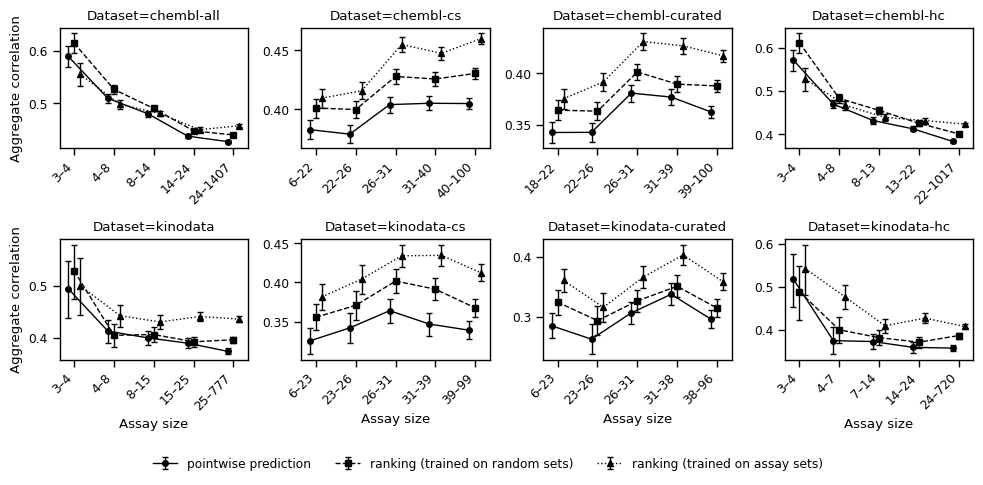

In [82]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_context("paper")

n_datasets = corrs.dataset.nunique()
fig, axes = plt.subplots(
    ncols=4, nrows=2, sharex=False, sharey=False, figsize=(10, 4.5)
)

linestyles = ["-", "--", ":", "-."]
markers = ["o", "s", "^", "D"]

for dataset, ax in zip(corrs.dataset.unique(), axes.flatten()):
    df_plot = bysize_q_analytical(corrs[corrs.dataset == dataset], q=5)

    if df_plot is None or df_plot.empty:
        continue

    # Map categorical quantile labels to numeric x-positions for dodging
    unique_quantiles = df_plot["quantile_label"].unique()
    q_map = {q: i for i, q in enumerate(unique_quantiles)}
    df_plot["x_pos"] = df_plot["quantile_label"].map(q_map)

    methods = df_plot["method"].unique()
    n_methods = len(methods)

    # Compute horizontal dodge offsets per method
    dodge_offsets = np.linspace(-0.15, 0.15, n_methods) if n_methods > 1 else [0]
    method_dodge = dict(zip(methods, dodge_offsets))

    for idx, m in enumerate(methods):
        sub = df_plot[df_plot["method"] == m]

        x = sub["x_pos"] + method_dodge[m]
        y = sub["pearson"]

        # Asymmetric yerr calculation relative to center y
        yerr_lower = y - sub["ci_lower"]
        yerr_upper = sub["ci_upper"] - y
        yerr = [yerr_lower.values, yerr_upper.values]

        ax.errorbar(
            x=x,
            y=y,
            yerr=yerr,
            label=m,
            color="black",
            linestyle=linestyles[idx % len(linestyles)],
            marker=markers[idx % len(markers)],
            markersize=4,
            linewidth=1,
            capsize=2,
            capthick=1,
        )

    # Set custom tick positions back to categorical labels
    ax.set_xticks(range(len(unique_quantiles)))
    ax.set_xticklabels(unique_quantiles, rotation=45, ha="right")
    ax.set_title(f"Dataset={dataset}")


axes[0, 0].set_ylabel("Aggregate correlation")
axes[1, 0].set_ylabel("Aggregate correlation")

for ax in axes[1, :]:
    ax.set_xlabel("Assay size")

handles, labels = [], []
ax = axes.flatten()[0]
h, l = ax.get_legend_handles_labels()
for handle, label in zip(h, l):
    if label not in labels:
        handles.append(handle)
        labels.append(method_labels[label])

if handles:
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        ncols=len(handles),  # Left-to-right horizontal alignment
        frameon=False,  # No border box
    )

plt.tight_layout()
plt.savefig("results_bysize_q.pdf", bbox_inches="tight")

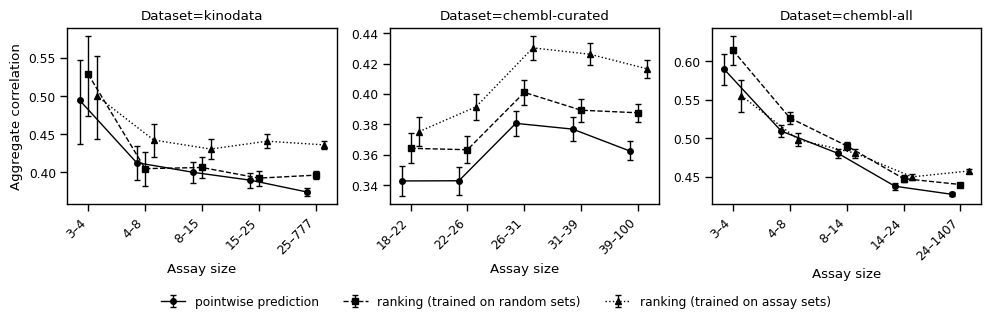

In [80]:

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_context("paper")

datasets = "kinodata chembl-curated chembl-all".split()
n_datasets = len(datasets)
fig, axes = plt.subplots(
    ncols=n_datasets, nrows=1, sharex=False, sharey=False, figsize=(10, 3)
)

linestyles = ["-", "--", ":", "-."]
markers = ["o", "s", "^", "D"]

for dataset, ax in zip(datasets, axes.flatten()):
    df_plot = bysize_q_analytical(corrs[corrs.dataset == dataset], q=5)

    if df_plot is None or df_plot.empty:
        continue

    # Map categorical quantile labels to numeric x-positions for dodging
    unique_quantiles = df_plot["quantile_label"].unique()
    q_map = {q: i for i, q in enumerate(unique_quantiles)}
    df_plot["x_pos"] = df_plot["quantile_label"].map(q_map)

    methods = df_plot["method"].unique()
    n_methods = len(methods)

    # Compute horizontal dodge offsets per method
    dodge_offsets = np.linspace(-0.15, 0.15, n_methods) if n_methods > 1 else [0]
    method_dodge = dict(zip(methods, dodge_offsets))

    for idx, m in enumerate(methods):
        sub = df_plot[df_plot["method"] == m]

        x = sub["x_pos"] + method_dodge[m]
        y = sub["pearson"]

        # Asymmetric yerr calculation relative to center y
        yerr_lower = y - sub["ci_lower"]
        yerr_upper = sub["ci_upper"] - y
        yerr = [yerr_lower.values, yerr_upper.values]

        ax.errorbar(
            x=x,
            y=y,
            yerr=yerr,
            label=m,
            color="black",
            linestyle=linestyles[idx % len(linestyles)],
            marker=markers[idx % len(markers)],
            markersize=4,
            linewidth=1,
            capsize=2,
            capthick=1,
        )

    # Set custom tick positions back to categorical labels
    ax.set_xticks(range(len(unique_quantiles)))
    ax.set_xticklabels(unique_quantiles, rotation=45, ha="right")
    ax.set_title(f"Dataset={dataset}")

# Apply global axis labels
axes[0].set_ylabel("Aggregate correlation")

for ax in axes:
    ax.set_xlabel("Assay size")


handles, labels = [], []
ax = axes.flatten()[0]
h, l = ax.get_legend_handles_labels()
for handle, label in zip(h, l):
    if label not in labels:
        handles.append(handle)
        labels.append(method_labels[label])

if handles:
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        ncols=len(handles),  # Left-to-right horizontal alignment
        frameon=False,  # No border box
    )
plt.tight_layout()
plt.savefig("results_bysize_q.pdf", bbox_inches="tight")

In [87]:
def plot_strat(ax1, ax2, overlap_corrs, non_overlap_corrs, dataset_name, typ, q=5, bottom=False):
    sns.set_context("paper")


    linestyles = ["-", "--", ":", "-."]
    markers = ["o", "s", "^", "D"]

    def plot_analytical_panel(ax, corrs_subset, title_suffix):
        if corrs_subset is None or len(corrs_subset) == 0:
            ax.set_title(title_suffix)
            return

        df_plot = bysize_q_analytical(corrs_subset, q=q)
        if df_plot is None or df_plot.empty:
            ax.set_title(title_suffix)
            return

        # Map quantiles to numeric positions for horizontal dodging
        unique_quantiles = df_plot["quantile_label"].unique()
        q_map = {q_val: i for i, q_val in enumerate(unique_quantiles)}
        df_plot["x_pos"] = df_plot["quantile_label"].map(q_map)

        methods = df_plot["method"].unique()
        n_methods = len(methods)

        # Calculate offsets matching the main figure
        dodge_offsets = (
            np.linspace(-0.15, 0.15, n_methods) if n_methods > 1 else [0]
        )
        method_dodge = dict(zip(methods, dodge_offsets))

        for idx, m in enumerate(methods):
            sub = df_plot[df_plot["method"] == m]

            x = sub["x_pos"] + method_dodge[m]
            y = sub["pearson"]

            # Asymmetric error bounds from Fisher-Z CI
            yerr_lower = y - sub["ci_lower"]
            yerr_upper = sub["ci_upper"] - y
            yerr = [yerr_lower.values, yerr_upper.values]

            ax.errorbar(
                x=x,
                y=y,
                yerr=yerr,
                label=m,
                color="black",
                linestyle=linestyles[idx % len(linestyles)],
                marker=markers[idx % len(markers)],
                markersize=4,
                linewidth=1,
                capsize=2,
                capthick=1,
            )

        ax.set_xticks(range(len(unique_quantiles)))
        ax.set_xticklabels(unique_quantiles, rotation=45, ha="right")
        ax.set_title(title_suffix)

    # Calculate assay counts safely
    n_overlap = (
        overlap_corrs["assay_id"].nunique()
        if overlap_corrs is not None and not overlap_corrs.empty
        else 0
    )
    n_non_overlap = (
        non_overlap_corrs["assay_id"].nunique()
        if non_overlap_corrs is not None and not non_overlap_corrs.empty
        else 0
    )

    plot_analytical_panel(ax1, overlap_corrs, f"{typ}-overlap ({n_overlap:,} assays)")
    plot_analytical_panel(
        ax2, non_overlap_corrs, f"no {typ}-overlap ({n_non_overlap:,} assays)"
    )

    if bottom:
        for ax in (ax1, ax2):
            ax.set_xlabel("Assay size")
            handles, labels = [], []
        ax = ax1


    ax1.set_ylabel("Aggregate correlation")
    ax2.set_ylabel("")


=> chembl-all


  0%|          | 0/5 [00:00<?, ?it/s]

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/omnivore/0/test.parquet'

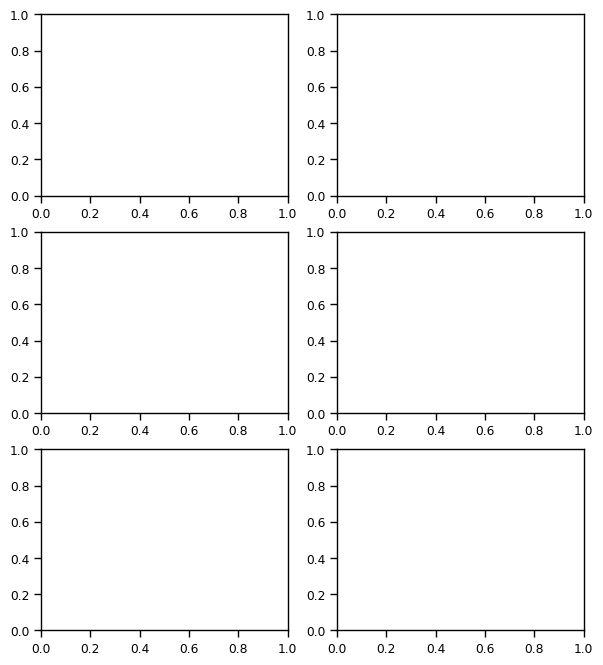

In [88]:
for dataset in corrs.dataset.unique():
    print("=>", dataset)
    fig, axes = plt.subplots(
        ncols=2, nrows=3, sharey=False, sharex=False, figsize=(7, 8)
    )
    overlaps_dataset, doc_overlaps_dataset, tgt_overlaps_dataset = overlaps(
        dataset
    )

    # 1. Document Overlaps
    non_overlap_corrs = corrs[
        (corrs["dataset"] == dataset)
        & (~corrs["assay_id"].isin(doc_overlaps_dataset))
    ]
    overlap_corrs = corrs[
        (corrs["dataset"] == dataset)
        & (corrs["assay_id"].isin(doc_overlaps_dataset))
    ]
    plot_strat(axes[1, 0], axes[1, 1], overlap_corrs, non_overlap_corrs, dataset, "doc")

    # 2. Measurement Overlaps
    non_overlap_corrs = corrs[
        (corrs["dataset"] == dataset)
        & (~corrs["assay_id"].isin(overlaps_dataset))
    ]
    overlap_corrs = corrs[
        (corrs["dataset"] == dataset)
        & (corrs["assay_id"].isin(overlaps_dataset))
    ]
    plot_strat(axes[0, 0], axes[0, 1], overlap_corrs, non_overlap_corrs, dataset, "measurement")

    # 3. Target Overlaps
    non_overlap_corrs = corrs[
        (corrs["dataset"] == dataset)
        & (~corrs["assay_id"].isin(tgt_overlaps_dataset))
    ]
    overlap_corrs = corrs[
        (corrs["dataset"] == dataset)
        & (corrs["assay_id"].isin(tgt_overlaps_dataset))
    ]
    plot_strat(axes[2, 0], axes[2, 1], overlap_corrs, non_overlap_corrs, dataset, "target", bottom=True)

    
    fig.suptitle(f"Dataset={dataset}")
    handles, labels = [], []
    ax = axes.flatten()[0]
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in labels:
            handles.append(handle)
            labels.append(method_labels[label])
    
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        ncols=len(handles),  # Left-to-right horizontal alignment
        frameon=False,  # No border box
    )
    plt.tight_layout()
    plt.savefig(f"{dataset}_overlap_strat.pdf", bbox_inches="tight")
    plt.close(fig)

## omnivore

In [ ]:
overlaps_omnivore, doc_overlaps_omnivore, tgt_overlaps_omnivore = overlaps("omnivore")

In [ ]:
sns.set_context("paper")
fig, (ax1, ax2) = plt.subplots(
    ncols=2, nrows=1, sharey=False, sharex=False, figsize=(7, 2.6)
)
sns.lineplot(
    bysize(overlap_corrs),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax1,
    legend=False,
    c="k",
)


sns.lineplot(
    bysize(non_overlap_corrs),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax2,
    legend=False,
    c="k",
)
ax1.set_xlabel("Assay size threshold")
ax2.set_xlabel("Assay size threshold")
ax1.set_xscale("log")
ax2.set_xscale("log")

ax1.set_ylabel("Aggregate correlation")
ax2.set_ylabel("")
ax1.set_title(f"with train/test overlap ({overlap_corrs['assay_id'].nunique()} assays)")
ax2.set_title(
    f"no train/test overlap ({non_overlap_corrs['assay_id'].nunique()} assays)"
)
fig.suptitle("Dataset=omnivore")
plt.tight_layout()
plt.savefig("performance_assaysize_overlaps.pdf")

In [ ]:
landrum = pd.read_csv("../data/raw/landrum.csv")

In [ ]:
landrum_assays = landrum["assay_id"].unique()

In [ ]:
# non_overlap_corrs_bad = non_overlap_corrs[
#     (non_overlap_corrs["dataset"] == "omnivore")
#     & (~non_overlap_corrs["assay_id"].isin(doc_overlaps))
#     & (~non_overlap_corrs["assay_id"].isin(landrum_assays))
# ]
# overlap_corrs_bad = overlap_corrs[
#     (overlap_corrs["dataset"] == "omnivore")
#     & (overlap_corrs["assay_id"].isin(doc_overlaps))
#     & (~overlap_corrs["assay_id"].isin(landrum_assays))
# ]
# non_overlap_corrs_good = non_overlap_corrs[
#     (non_overlap_corrs["dataset"] == "omnivore")
#     & (~non_overlap_corrs["assay_id"].isin(doc_overlaps))
#     & (non_overlap_corrs["assay_id"].isin(landrum_assays))
# ]
# overlap_corrs_good = overlap_corrs[
#     (overlap_corrs["dataset"] == "omnivore")
#     & (overlap_corrs["assay_id"].isin(doc_overlaps))
#     & (overlap_corrs["assay_id"].isin(landrum_assays))
# ]

non_overlap_corrs_bad = non_overlap_corrs[
    (non_overlap_corrs["dataset"] == "omnivore")
    & (~non_overlap_corrs["assay_id"].isin(doc_overlaps_omnivore))
    & (non_overlap_corrs["confidence_score"] != 9)
]
overlap_corrs_bad = overlap_corrs[
    (overlap_corrs["dataset"] == "omnivore")
    & (overlap_corrs["assay_id"].isin(doc_overlaps_omnivore))
    & (overlap_corrs["confidence_score"] != 9)
]
non_overlap_corrs_good = non_overlap_corrs[
    (non_overlap_corrs["dataset"] == "omnivore")
    & (~non_overlap_corrs["assay_id"].isin(doc_overlaps_omnivore))
    & (non_overlap_corrs["confidence_score"] == 9)
]
overlap_corrs_good = overlap_corrs[
    (overlap_corrs["dataset"] == "omnivore")
    & (overlap_corrs["assay_id"].isin(doc_overlaps_omnivore))
    & (overlap_corrs["confidence_score"] == 9)
]

In [ ]:
len(non_overlap_corrs_bad), len(overlap_corrs_bad)

In [ ]:
sns.set_context("paper")
fig, ((ax2, ax1), (ax4, ax3)) = plt.subplots(
    ncols=2, nrows=2, sharey=False, sharex=False, figsize=(7, 6)
)
sns.lineplot(
    bysize_q(non_overlap_corrs_good),
    style="method",
    # hue="dataset",
    y="pearson",
    x="quantile_label",
    ax=ax1,
    legend=True,
    c="k",
)


sns.lineplot(
    bysize_q(overlap_corrs_good),
    style="method",
    # hue="dataset",
    y="pearson",
    x="quantile_label",
    ax=ax2,
    legend=True,
    c="k",
)
# ax1.set_xlabel("Assay size threshold")
# ax2.set_xlabel("Assay size threshold")
# ax1.set_xscale("log")
# ax2.set_xscale("log")


sns.lineplot(
    bysize_q(non_overlap_corrs_bad),
    style="method",
    # hue="dataset",
    y="pearson",
    x="quantile_label",
    ax=ax3,
    legend=True,
    c="k",
)


sns.lineplot(
    bysize_q(overlap_corrs_bad),
    style="method",
    # hue="dataset",
    y="pearson",
    x="quantile_label",
    ax=ax4,
    legend=True,
    c="k",
)
ax3.set_xlabel("Assay size threshold")
ax4.set_xlabel("Assay size threshold")
# ax3.set_xscale("log")
# ax4.set_xscale("log")

ax1.set_xlabel("")
ax2.set_xlabel("")
ax2.set_ylabel("Aggregate correlation")
ax1.set_ylabel("")
ax4.set_ylabel("Aggregate correlation")
ax3.set_ylabel("")
ax2.set_title(
    f"good with train/test overlap ({overlap_corrs_good['assay_id'].nunique()} assays)"
)
ax1.set_title(
    f"good no train/test overlap ({non_overlap_corrs_good['assay_id'].nunique()} assays)"
)
ax4.set_title(
    f"bad with train/test overlap ({overlap_corrs_bad['assay_id'].nunique()} assays)"
)
ax3.set_title(
    f"bad no train/test overlap ({non_overlap_corrs_bad['assay_id'].nunique()} assays)"
)
fig.suptitle("Dataset=omnivore")
plt.tight_layout()
plt.savefig("omnivore_bysize_goodbad_overlap.pdf")

## landrum

In [ ]:
overlaps_landrum, doc_overlaps_landrum, tgt_overlaps_landrum = overlaps("landrum")

In [ ]:
non_overlap_corrs_landrum = corrs[
    (corrs["dataset"] == "landrum") & (~corrs["assay_id"].isin(overlaps_landrum))
]
overlap_corrs_landrum = corrs[
    (corrs["dataset"] == "landrum") & (corrs["assay_id"].isin(overlaps_landrum))
]

In [ ]:
non_overlap_corrs = corrs[
    (corrs["dataset"] == "landrum") & (~corrs["assay_id"].isin(doc_overlaps_landrum))
] 
overlap_corrs = corrs[
    (corrs["dataset"] == "landrum") & (corrs["assay_id"].isin(doc_overlaps_landrum))
]

bysize_non_overlap = bysize_q(non_overlap_corrs)
bysize_overlap = bysize_q(overlap_corrs)

plot_strat(bysize_overlap, bysize_non_overlap, "landrum", "doc")

In [ ]:
non_overlap_corrs = corrs[
    (corrs["dataset"] == "landrum") & (~corrs["assay_id"].isin(overlaps_landrum))
] 
overlap_corrs = corrs[
    (corrs["dataset"] == "landrum") & (corrs["assay_id"].isin(overlaps_landrum))
]

bysize_non_overlap = bysize_q(non_overlap_corrs)
bysize_overlap = bysize_q(overlap_corrs)

plot_strat(bysize_overlap, bysize_non_overlap, "landrum", "measurement")

In [ ]:
non_overlap_corrs = corrs[
    (corrs["dataset"] == "landrum") & (~corrs["assay_id"].isin(tgt_overlaps_landrum))
] 
overlap_corrs = corrs[
    (corrs["dataset"] == "landrum") & (corrs["assay_id"].isin(tgt_overlaps_landrum))
]

bysize_non_overlap = bysize_q(non_overlap_corrs)
bysize_overlap = bysize_q(overlap_corrs)

plot_strat(bysize_overlap, bysize_non_overlap, "landrum", "target")

In [ ]:
bysize_non_overlap = bysize_q(non_overlap_corrs_landrum)
bysize_overlap = bysize_q(overlap_corrs_landrum)
sns.set_context("paper")
fig, (ax1, ax2) = plt.subplots(
    ncols=2, nrows=1, sharey=False, sharex=False, figsize=(7, 3)
)
sns.lineplot(
    bysize_overlap,
    style="method",
    # hue="dataset",
    y="pearson",
    x="quantile_label",
    ax=ax1,
    legend=False,
    c="k",
)


sns.lineplot(
    bysize_non_overlap,
    style="method",
    # hue="dataset",
    y="pearson",
    x="quantile_label",
    ax=ax2,
    legend=True,
    c="k",
)
for ax in (ax1, ax2):
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel("Assay size")

ax1.set_ylabel("Aggregate correlation")
ax2.set_ylabel("")
ax1.set_title(f"with train/test overlap ({overlap_corrs_landrum['assay_id'].nunique()} assays)")
ax2.set_title(
    f"no train/test overlap ({non_overlap_corrs_landrum['assay_id'].nunique()} assays)"
)
fig.suptitle("Dataset=landrum")
plt.tight_layout()

In [ ]:
sns.set_context("paper")
fig, (ax1, ax2) = plt.subplots(
    ncols=2, nrows=1, sharey=False, sharex=False, figsize=(7, 2.6)
)
sns.lineplot(
    bysize(overlap_corrs),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax1,
    legend=False,
    c="k",
)


sns.lineplot(
    bysize(non_overlap_corrs),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax2,
    legend=False,
    c="k",
)
ax1.set_xlabel("Assay size threshold")
ax2.set_xlabel("Assay size threshold")
ax1.set_xscale("log")
ax2.set_xscale("log")
ax2.set_ylim(0.25, None)
ax1.set_ylim(None, 0.6)

ax1.set_ylabel("Aggregate correlation")
ax2.set_ylabel("")
ax1.set_title(f"with train/test overlap ({overlap_corrs['assay_id'].nunique()} assays)")
ax2.set_title(
    f"no train/test overlap ({non_overlap_corrs['assay_id'].nunique()} assays)"
)
fig.suptitle("Dataset=landrum")
plt.tight_layout()
plt.savefig("performance_assaysize_overlaps_landrum.pdf")

## kinodata

In [ ]:
kinodata = pd.read_csv("../data/raw/activities-chembl33_v0.5.csv", index_col=0)
kinodata.columns

In [ ]:
kinodata.groupby("assays.chembl_id")[["docs.chembl_id"]].nunique().value_counts()

In [ ]:
kinodata.groupby("docs.chembl_id")[["assays.chembl_id"]].nunique()

In [ ]:
doc_overlaps = []
tgt_overlaps = []
overlaps_kinodata = []
doc_overlaps_kinodata = []
for fold in tqdm.tqdm(range(5)):
    test = pd.read_csv(f"../data/processed/kinodata/{fold}/test.csv", index_col=0)
    train = pd.read_csv(f"../data/processed/kinodata/{fold}/train.csv", index_col=0)
    duplicates = test.merge(
        train[["compound_id", "assay_id", "target", "activity_value"]],
        on=["compound_id", "target", "activity_value"],
        how="inner",
    )
    overlaps_kinodata.append(duplicates["assay_id_x"].unique())
    duplicate_docs = np.intersect1d(test['docs.chembl_id'].unique(), train['docs.chembl_id'].unique())
    doc_overlaps.append(test[test['docs.chembl_id'].isin(duplicate_docs)]['assay_id'].unique())
    duplicate_tgts = np.intersect1d(test['target'].unique(), train['target'].unique())
    tgt_overlaps.append(test[test['target'].isin(duplicate_tgts)]['assay_id'].unique())

overlaps_kinodata = np.unique(np.concat(overlaps_kinodata))
doc_overlaps_kinodata = np.unique(np.concat(doc_overlaps))
tgt_overlaps_kinodata = np.unique(np.concat(tgt_overlaps))
print(overlaps_kinodata.shape)

In [ ]:
len(overlaps_kinodata)

In [ ]:
len(doc_overlaps_kinodata)

In [ ]:
len(tgt_overlaps_kinodata)

In [ ]:
kinodata['assays.chembl_id'].nunique()

In [ ]:
kinodata['assays.confidence_score'].value_counts()

In [ ]:
corrs['confidence_score'].value_counts()

In [ ]:
non_overlap_corrs_kinodata = corrs[
    (corrs["dataset"] == "kinodata") & (~corrs["assay_id"].isin(tgt_overlaps_kinodata))
]
overlap_corrs_kinodata = corrs[
    (corrs["dataset"] == "kinodata") & (corrs["assay_id"].isin(tgt_overlaps_kinodata))
]

bysize_non_overlap = bysize_q(non_overlap_corrs_kinodata)
bysize_overlap = bysize_q(overlap_corrs_kinodata)

plot_strat(bysize_overlap, bysize_non_overlap, "kinodata", "target")

In [ ]:
non_overlap_corrs_kinodata = corrs[
    (corrs["dataset"] == "kinodata") & (~corrs["assay_id"].isin(doc_overlaps_kinodata))
]
overlap_corrs_kinodata = corrs[
    (corrs["dataset"] == "kinodata") & (corrs["assay_id"].isin(doc_overlaps_kinodata))
]

bysize_non_overlap = bysize_q(non_overlap_corrs_kinodata)
bysize_overlap = bysize_q(overlap_corrs_kinodata)

plot_strat(bysize_overlap, bysize_non_overlap, "kinodata", "document")

In [ ]:
non_overlap_corrs_kinodata = corrs[
    (corrs["dataset"] == "kinodata") & (corrs["confidence_score"] != 9.0)
]
overlap_corrs_kinodata = corrs[
    (corrs["dataset"] == "kinodata") & (corrs["confidence_score"] == 9.0)
]

bysize_non_overlap = bysize_q(non_overlap_corrs_kinodata)
bysize_overlap = bysize_q(overlap_corrs_kinodata)

plot_strat(bysize_overlap, bysize_non_overlap, "kinodata", "clean")

In [ ]:
kinodata['assays.confidence_score'].value_counts()

In [ ]:
len(kinodata)

In [ ]:
sns.set_context("paper")
fig, (ax1, ax2) = plt.subplots(
    ncols=2, nrows=1, sharey=False, sharex=False, figsize=(7, 2.6)
)
sns.lineplot(
    bysize(overlap_corrs),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax1,
    legend=False,
    c="k",
)


sns.lineplot(
    bysize(non_overlap_corrs),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax2,
    legend=False,
    c="k",
)
ax1.set_xlabel("Assay size threshold")
ax2.set_xlabel("Assay size threshold")
ax1.set_xscale("log")
ax2.set_xscale("log")
ax2.set_ylim(0.25, None)
ax1.set_ylim(None, 0.6)

ax1.set_ylabel("Aggregate correlation")
ax2.set_ylabel("")
ax1.set_title(f"with train/test overlap ({overlap_corrs['assay_id'].nunique()} assays)")
ax2.set_title(
    f"no train/test overlap ({non_overlap_corrs['assay_id'].nunique()} assays)"
)
fig.suptitle("Dataset=kinodata")
plt.tight_layout()
plt.savefig("performance_assaysize_overlaps_kinodata.pdf")

In [ ]:
non_overlap_corrs_bad = non_overlap_corrs[
    (non_overlap_corrs["dataset"] == "kinodata")
    & (~non_overlap_corrs["assay_id"].isin(overlaps_kinodata))
    & (non_overlap_corrs["confidence_score"] < 9)
]
overlap_corrs_bad = overlap_corrs[
    (overlap_corrs["dataset"] == "kinodata")
    & (overlap_corrs["assay_id"].isin(overlaps_kinodata))
    & (overlap_corrs["confidence_score"] < 9)
]
non_overlap_corrs_good = non_overlap_corrs[
    (non_overlap_corrs["dataset"] == "kinodata")
    & (~non_overlap_corrs["assay_id"].isin(overlaps))
    & (non_overlap_corrs["confidence_score"] == 9)
]
overlap_corrs_good = overlap_corrs[
    (overlap_corrs["dataset"] == "kinodata")
    & (overlap_corrs["assay_id"].isin(overlaps))
    & (overlap_corrs["confidence_score"] == 9)
]

In [ ]:
sns.set_context("paper")
fig, ((ax2, ax1), (ax4, ax3)) = plt.subplots(
    ncols=2, nrows=2, sharey=False, sharex=False, figsize=(7, 6)
)
sns.lineplot(
    bysize(non_overlap_corrs_good),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax1,
    legend=True,
    c="k",
)


sns.lineplot(
    bysize(overlap_corrs_good),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax2,
    legend=True,
    c="k",
)
# ax1.set_xlabel("Assay size threshold")
# ax2.set_xlabel("Assay size threshold")
ax1.set_xscale("log")
ax2.set_xscale("log")


sns.lineplot(
    bysize(non_overlap_corrs_bad),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax3,
    legend=True,
    c="k",
)


sns.lineplot(
    bysize(overlap_corrs_bad),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax4,
    legend=True,
    c="k",
)
ax3.set_xlabel("Assay size threshold")
ax4.set_xlabel("Assay size threshold")
ax3.set_xscale("log")
ax4.set_xscale("log")

ax2.set_ylabel("Aggregate correlation")
ax1.set_ylabel("")
ax4.set_ylabel("Aggregate correlation")
ax3.set_ylabel("")
ax2.set_title(
    f"good with train/test overlap ({overlap_corrs_good['assay_id'].nunique()} assays)"
)
ax1.set_title(
    f"good no train/test overlap ({non_overlap_corrs_good['assay_id'].nunique()} assays)"
)
ax4.set_title(
    f"bad with train/test overlap ({overlap_corrs_bad['assay_id'].nunique()} assays)"
)
ax3.set_title(
    f"bad no train/test overlap ({non_overlap_corrs_bad['assay_id'].nunique()} assays)"
)
fig.suptitle("Dataset=omnivore")
plt.tight_layout()

In [ ]:
sns.scatterplot(
    data=df[df["method"] == "ic50"],
    x="prediction",
    y="label",
    hue="dataset",
    size=1,
    alpha=0.2,
)

In [ ]:
for dataset in corrs.dataset.unique():
    overlaps_dataset, doc_overlaps_dataset, tgt_overlaps_dataset = overlaps("dataset")
    
    non_overlap_corrs = corrs[
        (corrs["dataset"] == "dataset") & (~corrs["assay_id"].isin(doc_overlaps_dataset))
    ] 
    overlap_corrs = corrs[
        (corrs["dataset"] == "dataset") & (corrs["assay_id"].isin(doc_overlaps_dataset))
    ]
    
    bysize_non_overlap = bysize_q(non_overlap_corrs)
    bysize_overlap = bysize_q(overlap_corrs)
    
    plot_strat(bysize_overlap, bysize_non_overlap, "dataset", "doc")
    
    non_overlap_corrs = corrs[
        (corrs["dataset"] == "dataset") & (~corrs["assay_id"].isin(overlaps_dataset))
    ] 
    overlap_corrs = corrs[
        (corrs["dataset"] == "dataset") & (corrs["assay_id"].isin(overlaps_dataset))
    ]
    
    bysize_non_overlap = bysize_q(non_overlap_corrs)
    bysize_overlap = bysize_q(overlap_corrs)
    
    plot_strat(bysize_overlap, bysize_non_overlap, "dataset", "measurement")
    
    non_overlap_corrs = corrs[
        (corrs["dataset"] == "dataset") & (~corrs["assay_id"].isin(tgt_overlaps_dataset))
    ] 
    overlap_corrs = corrs[
        (corrs["dataset"] == "dataset") & (corrs["assay_id"].isin(tgt_overlaps_dataset))
    ]
    
    bysize_non_overlap = bysize_q(non_overlap_corrs)
    bysize_overlap = bysize_q(overlap_corrs)
    
    plot_strat(bysize_overlap, bysize_non_overlap, "dataset", "target")